### Report Maciej Janicki, Wojciech Bogacz

### Dependencies


In [417]:
import numpy as np
import glob
import matplotlib.pyplot as plt
import sklearn
import cvxopt
import math
import random
cvxopt.solvers.options['show_progress'] = False

### Load Data

Results in `stocks` dictionary

In [418]:
def load_stock_data(filename):
    with open(filename, "r") as file:
        name : str
        n : int
        datapoints = []
        for i, line in enumerate(file):
            line = line.strip()
            if i == 0:
                name = line
            elif i == 1:
                n = int(line)
            else:
                _, point = line.split(" ")
                point = float(point)
                datapoints.append(point)
        assert(len(datapoints) == n)
        return name, np.array(datapoints)

In [419]:
stocks = {}
for stock_filename in glob.glob("bundle1/*.txt"):
    name, datapoints = load_stock_data(stock_filename)
    stocks[name] = datapoints
print(f"Loaded {len(stocks)} stocks")

Loaded 20 stocks


### Prediction functions and curves
esults in `stocks_predicted_ratios` dictionary.

In [420]:
# def linear_regression_prediction(datapoints, n_past_samples):
#     x = np.arange(n_past_samples,len(datapoints)).reshape(-1, 1)
#     print(x)
#     reg = sklearn.linear_model.LinearRegression().fit(x, datapoints[n_past_samples:])
#     err = np.std(datapoints[n_past_samples:] - reg.predict(x))
#     px = np.arange(len(datapoints), len(datapoints) + 100).reshape(-1, 1) # go to next T
#     return np.clip(reg.predict(px), a_min=err, a_max=np.inf), err

def create_harmonic_elements(x, harmonic_order, period_len):
    intercept = np.ones_like(x)
    components = [intercept, x]
    for order in range(1, harmonic_order+1):
        zx = 2 * np.pi * order * x / period_len
        comp = np.sin(zx) + np.cos(zx)
        components.append(comp)
    components = np.column_stack(components)
    return components
    

def harmonic_regression_prediction(datapoints, harmonic_order, period_len):
    x = create_harmonic_elements(np.arange(len(datapoints)), harmonic_order, period_len)
    reg = sklearn.linear_model.BayesianRidge().fit(x, np.log(datapoints))
    err = np.std(datapoints - np.exp(reg.predict(x)))

    px = create_harmonic_elements(np.arange(len(datapoints), len(datapoints) + 100), harmonic_order, period_len) # go to next T
    return np.exp(reg.predict(px)), err




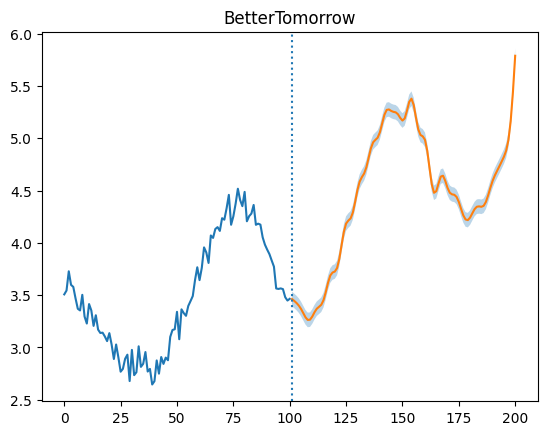

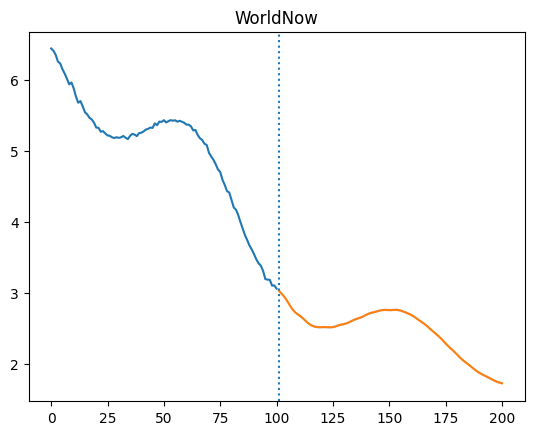

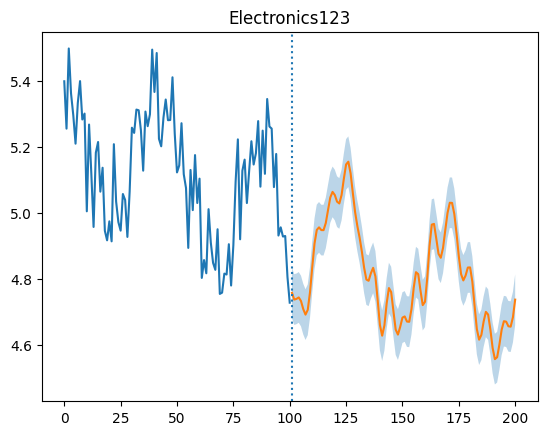

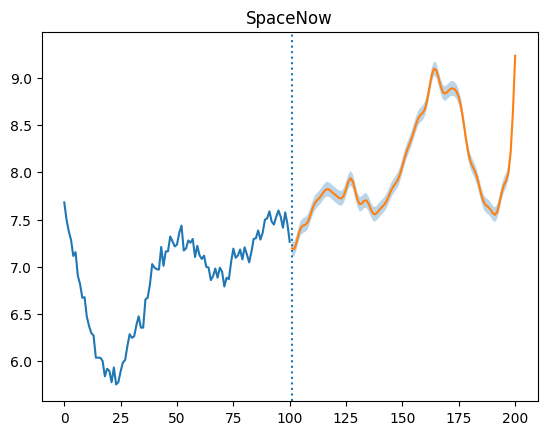

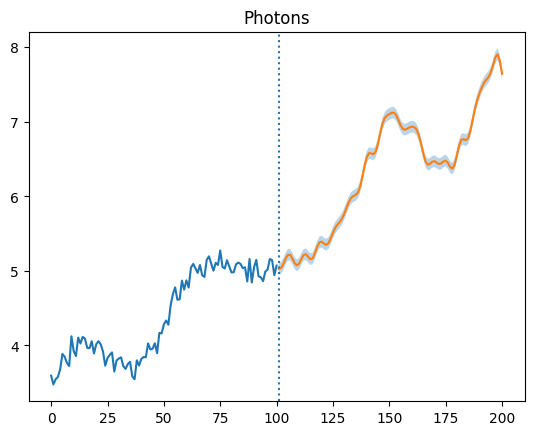

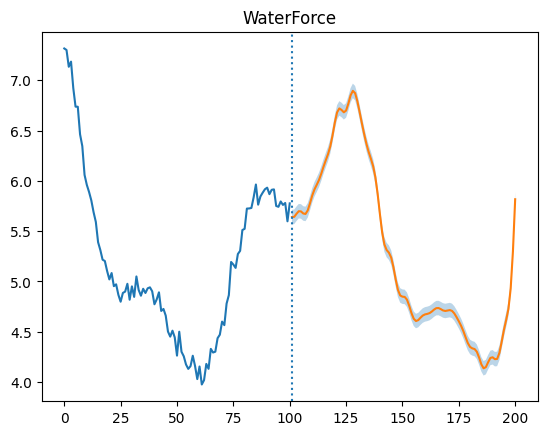

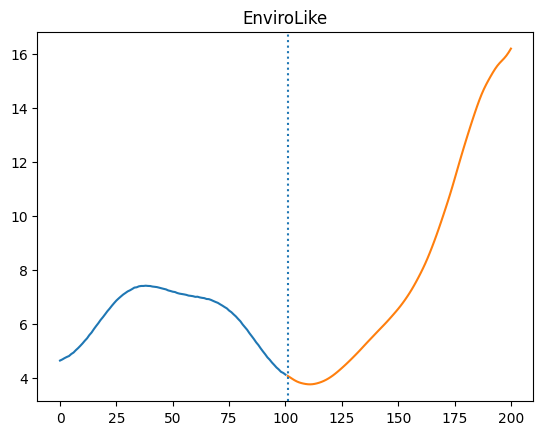

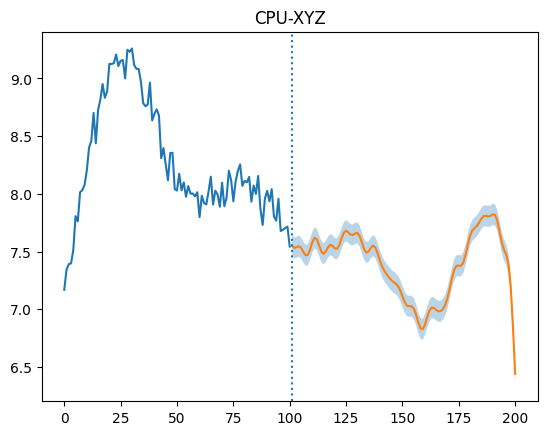

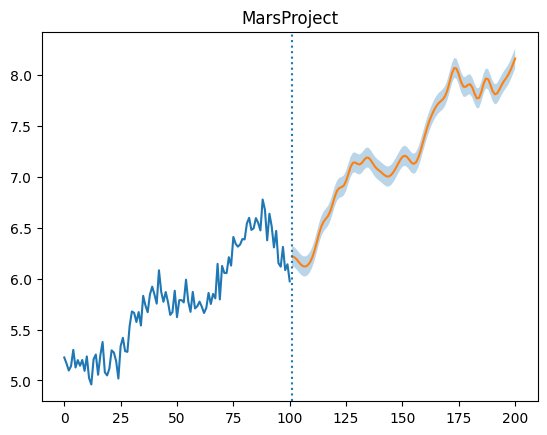

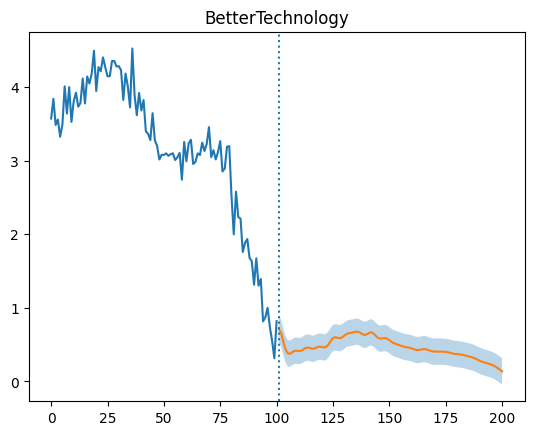

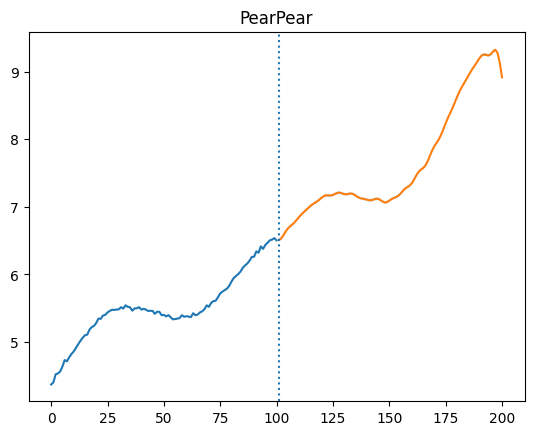

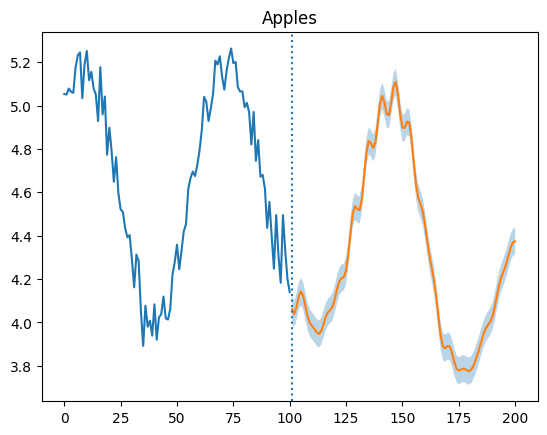

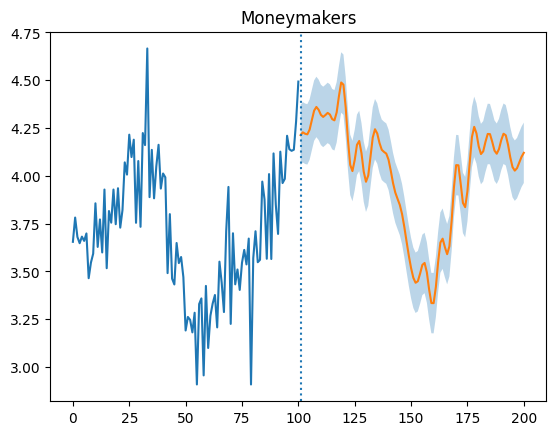

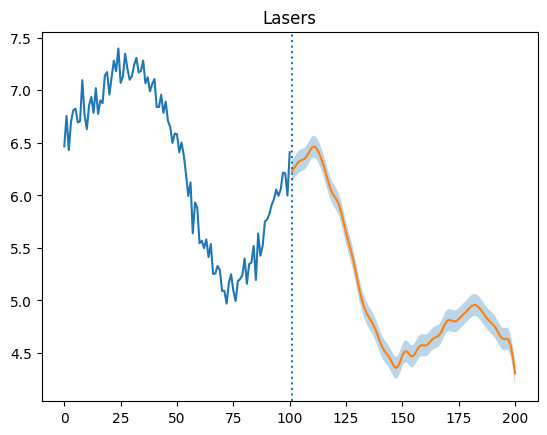

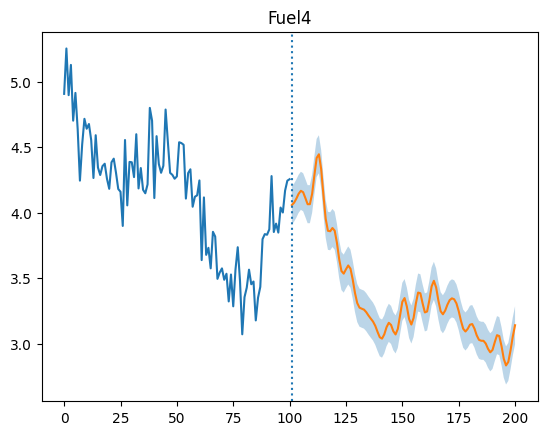

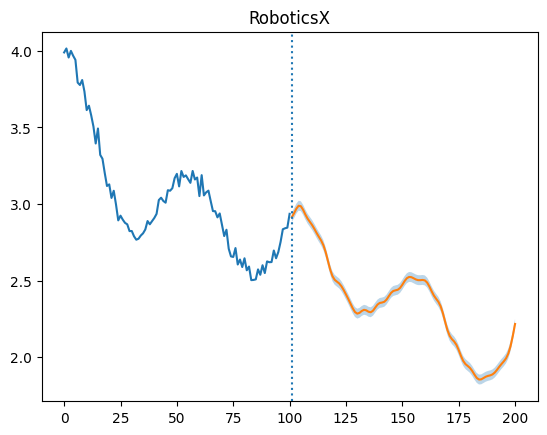

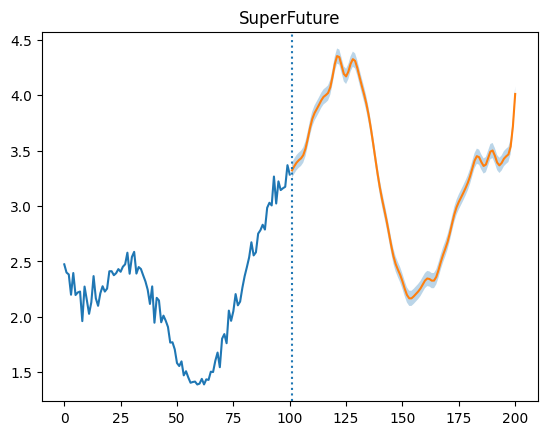

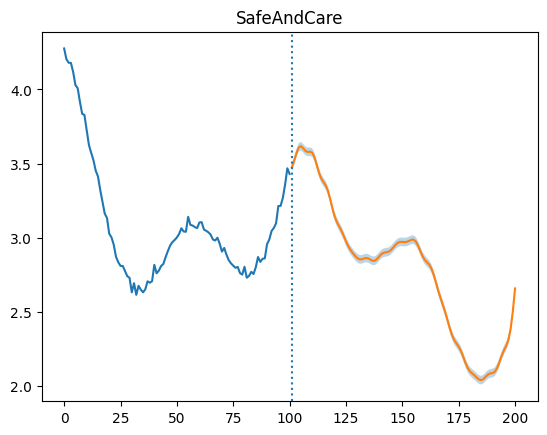

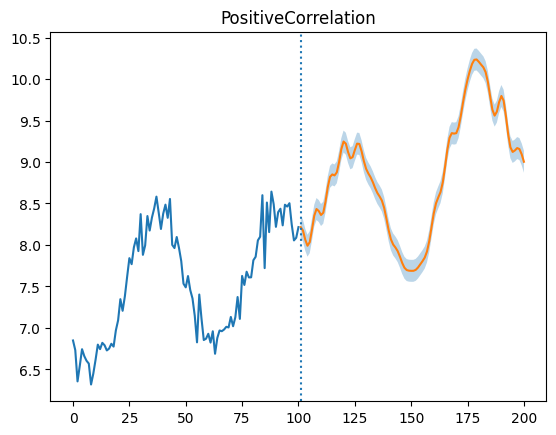

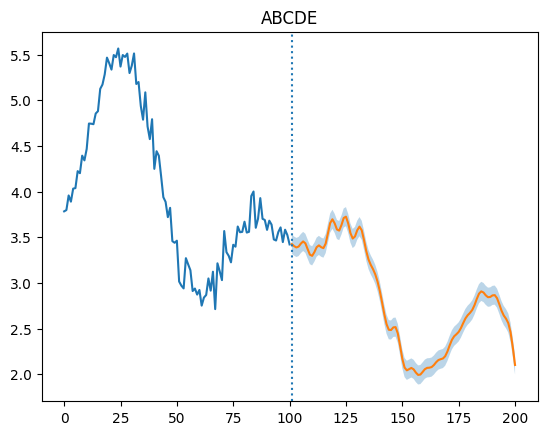

In [421]:
stocks_predicted_ratios = {} # predictions for last day only
harmonic_order=35
period_len=201
stock_predicted_values = {}
for stock_name, stock_datapoints in stocks.items():
    predictions, err = harmonic_regression_prediction(stock_datapoints,harmonic_order, period_len)
    
    stocks_predicted_ratios[stock_name] = predictions[-1] / stock_datapoints[-1]
    x = np.arange(len(stock_datapoints))
    plt.plot(x, stock_datapoints)
    px = np.arange(len(stock_datapoints), len(stock_datapoints) + 100)
    plt.plot(px, predictions)
    stock_predicted_values[stock_name] = predictions
    plt.axvline(len(stock_datapoints), linestyle="dotted")
    plt.fill_between(px, predictions - err, predictions + err, alpha=0.3)
    plt.title(stock_name)
    plt.show()


In [422]:
print(stocks_predicted_ratios)

{'BetterTomorrow': np.float64(1.6703633564854843), 'WorldNow': np.float64(0.564535263124032), 'Electronics123': np.float64(1.0019520109057287), 'SpaceNow': np.float64(1.271115851964351), 'Photons': np.float64(1.5071908150418776), 'WaterForce': np.float64(1.007117375827805), 'EnviroLike': np.float64(3.9251395313565594), 'CPU-XYZ': np.float64(0.853762720946338), 'MarsProject': np.float64(1.3664732289808967), 'BetterTechnology': np.float64(0.1673966281666613), 'PearPear': np.float64(1.3711437327051674), 'Apples': np.float64(1.056607173466597), 'Moneymakers': np.float64(0.9171113775912372), 'Lasers': np.float64(0.6716113239120197), 'Fuel4': np.float64(0.7380583260253248), 'RoboticsX': np.float64(0.7552222232805703), 'SuperFuture': np.float64(1.2213139383200515), 'SafeAndCare': np.float64(0.7744835752975817), 'PositiveCorrelation': np.float64(1.0958813104398002), 'ABCDE': np.float64(0.6142371555145255)}


### Covariance

Results in `stocks_covariance` matrix and `stocks_expected_return` vector

In [423]:
m = []
stocks_expected_return = []
for stock in stocks:
    m.append(stocks[stock])
    stocks_expected_return.append(stocks_predicted_ratios[stock])
m = np.array(m)
stocks_covariance = np.cov(m)
stocks_expected_return = np.array(stocks_expected_return) - 1

In [426]:
def evaluate_solution(weights, expected_return, covariance_matrix):
    return np.sum(weights * (expected_return)), weights.T @ covariance_matrix @ weights

eigvals = np.linalg.eigvalsh(stocks_covariance)
min_risk = eigvals.min()
max_risk = eigvals.max()
max_return = np.max(stocks_expected_return)
min_return = np.min(stocks_expected_return)

print(min_return, max_return, min_risk, max_risk)

-0.8326033718333388 2.9251395313565594 0.0003065737954134563 3.5074922072047974


1 [0.00110761 0.31477415]
2 [0.00127476 0.33189342]
3 [0.00070499 0.31246351]
4 [0.00211951 0.38495533]
5 [0.00603569 0.42293505]
6 [0.00211951 0.38495533]
7 [0.00888464 0.44790395]
8 [0.00933233 0.45544613]
9 [0.00077973 0.34946639]
10 [0.00116988 0.38542571]
11 [0.00116988 0.38542571]
12 [0.00324414 0.43775531]
13 [0.01249843 0.48799074]
14 [0.00679965 0.45873743]
15 [0.01765436 0.52705585]
16 [0.01631186 0.52375768]
17 [0.01631186 0.52375768]
18 [0.00411996 0.45019091]
19 [0.01765436 0.52705585]
20 [0.02002688 0.5291336 ]
21 [0.02002688 0.5291336 ]
22 [0.00748    0.48451839]
23 [0.02002688 0.5291336 ]
24 [0.02002688 0.5291336 ]
25 [0.02002688 0.5291336 ]
26 [0.02002688 0.5291336 ]
27 [0.02002688 0.5291336 ]
28 [0.0012567  0.38598717]
29 [0.0012567  0.38598717]
30 [0.0012567  0.38598717]
31 [0.00155428 0.39596245]
32 [0.00450299 0.45148269]
33 [0.00411996 0.45019091]
34 [0.00155428 0.39596245]
35 [0.00155428 0.39596245]
36 [0.00155428 0.39596245]
37 [0.00155428 0.39596245]
38 [0.0015

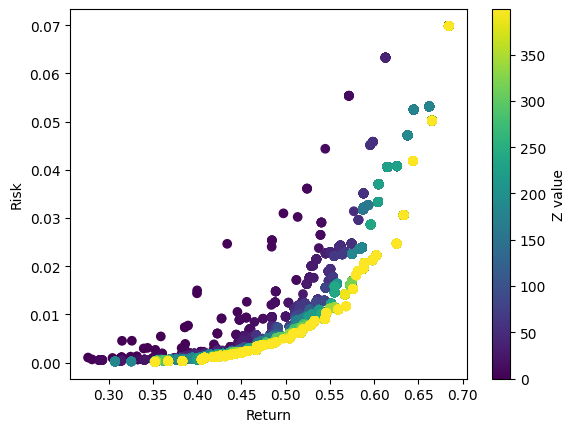

In [453]:

def evaluate_population(population):
    risk = np.sum((population @ stocks_covariance) * population, axis=1)
    risk = (risk - min_risk) / (max_risk - min_risk)
    ret = np.sum(population * stocks_expected_return, axis=1)
    ret = (ret - min_return) / (max_return - min_return)

    return np.column_stack((risk, ret))

def get_crowding_distance(front, criteria):
    n = len(front)
    if n == 0:
        return []

    distances = [0.0] * n

    num_objectives = len(criteria[0])

    for m in range(num_objectives):
        sorted_idx = sorted(range(n), key=lambda i: criteria[front[i]][m])

        distances[sorted_idx[0]] = math.inf
        distances[sorted_idx[-1]] = math.inf

        for i in range(1, n - 1):
            prev_val = criteria[front[sorted_idx[i - 1]]][m]
            next_val = criteria[front[sorted_idx[i + 1]]][m]

            distances[sorted_idx[i]] += float((next_val - prev_val) / 2)
    return distances

            
def dominates(a, b):
    return (
        (a[0] <= b[0] and a[1] >= b[1]) and
        (a[0] < b[0] or a[1] > b[1])
    )

def ngsa2_sort(population, criteria):
    order = []
    pareto_front = []
    to_check = [i for i in range(len(population))]
    while len(to_check) > 0:
        non_dominated = []
        next_to_check = []
        for i in to_check:
            nd = True
            for j in to_check:
                if dominates(criteria[j], criteria[i]):
                    nd = False
                    break
            if nd:
                non_dominated.append(i)
            else:
                next_to_check.append(i)
        to_check = next_to_check
        cd = get_crowding_distance(non_dominated, criteria)
        if len(order) == 0:
            pareto_front = non_dominated
        order += [x for _, x in sorted(zip(cd, non_dominated), key=lambda pair: pair[0], reverse=False)]
    
    return np.array([population[o] for o in order]), pareto_front

def fix(population):
    return population / population.sum(axis=1, keepdims=True)

def crossover(p1, p2):
    u = random.random()
    nc = 20
    if u < 0.5:
        beta = math.pow(2 * u, 1/(nc+1))
    else:
        beta = math.pow( 1 / (2 * (1-u)), 1/(nc+1))
    c1 = 0.5 * ((1+beta) * p1 + (1-beta) * p2)
    c2 = 0.5 * ((1-beta) * p1 + (1+beta) * p2)
    return c1, c2

def mutate(c):
    return np.clip(c + np.random.normal(loc=0.0, scale=0.05, size=len(c)), 0.0, 1.0)

def roulette_wheel_selection(population, n_offspring):
    def parent_toss():
        return int(round(-math.log(random.random(), 1.15)))
    offspring = []
    for _ in range(n_offspring//2):
        p1, p2 = parent_toss(), parent_toss()
        c1, c2 = crossover(population[p1], population[p2])
        offspring.append(mutate(c1))
        offspring.append(mutate(c2))
    return fix(np.array(offspring))



pop_size = 300
generations = 400



population = np.random.random((pop_size, len(stocks_expected_return)))
population = fix(population)
criteria = evaluate_population(population)
population, front = ngsa2_sort(population, criteria)
pareto_history_x = list(criteria[front, 1])
pareto_history_y = list(criteria[front, 0])
pareto_history_z = [0] * len(criteria[front, 0])


for g in range(1, generations):

    offspring = roulette_wheel_selection(population, int(pop_size * 0.2))
    population = np.vstack((population, offspring))
    criteria = evaluate_population(population)

    population, front = ngsa2_sort(population, criteria)

    population = population[:pop_size]
    pareto_history_x += list(criteria[front, 1])
    pareto_history_y += list(criteria[front, 0])
    pareto_history_z += [g] * len(criteria[front, 0])    
    print(g, criteria[front[0]])

plt.scatter(pareto_history_x, pareto_history_y, c=pareto_history_z)
plt.colorbar(label='Z value')
plt.xlabel('Return')
plt.ylabel('Risk')
plt.show()